# Titanic Surival Prediction with Logistic Regression from Scratch

---

## Goal

---

Build and understand a complete binary logistic regression workflow
using only NumPy and pandas. The implementation includes:
- data preparation
- train/test splitting
- feature standardization
- sigmoid activation
- binary cross-entropy loss
- gradient descent optimization
- prediction and evaluation

## 2. Imports and Configurations

---

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[1]
SRC_PATH = PROJECT_ROOT / "00_classification_model" / "src"

sys.path.append(str(SRC_PATH))

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from classification_model.data.preprocessing import (
    standardize_data,
    train_test_split_numpy,
)
from classification_model.evaluation.metrics import (
    accuracy,
    confusion_matrix,
    f1_score,
    precision,
    recall,
)
from classification_model.models.logistic_regression import LogisticRegressionScratch

In [3]:
DATA_PATH = "../data_raw/titanic.csv"

TARGET_COLUMN = "survived"

TEST_SIZE = 0.2
RANDOM_STATE = 42

## 3. Load Dataset

---


In [4]:
df = pd.read_csv(DATA_PATH)

## 4. Prepare feature and targets

---
Split the dataset into input features (`X`) and target labels (`y`).

In [5]:
y = df[TARGET_COLUMN]
X = df.drop(columns=[TARGET_COLUMN])

# 5 Train Test Split

---

Split in Training and Testing set


In [6]:
X_train, X_test, y_train, y_test = train_test_split_numpy(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

In [7]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (710, 7)
X_test shape: (177, 7)
y_train shape: (710,)
y_test shape: (177,)


## 6. Feature Scaling

---

Continuous numerical features are standardized using costum standardization function to improve optimization stability and model performance.

In [8]:
continuous_features = ["age", "fare", "family_size"]

X_train[continuous_features], X_test[continuous_features] = standardize_data(
    X_train[continuous_features],
    X_test[continuous_features],
)

In [9]:
X_train.describe()

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class
count,710.000000,7.100000e+02,7.100000e+02,7.100000e+02,710.000000,710.000000,710.000000
mean,0.646479,4.003058e-17,-4.503440e-17,5.504204e-17,0.230986,0.212676,0.556338
std,0.478400,1.000000e+00,1.000000e+00,1.000000e+00,0.421761,0.409489,0.497166
min,0.000000,-2.068603e+00,-5.545847e-01,-6.916341e-01,0.000000,0.000000,0.000000
25%,0.000000,-6.487794e-01,-5.545847e-01,-5.156841e-01,0.000000,0.000000,0.000000
50%,1.000000,-6.866767e-02,-5.545847e-01,-3.707235e-01,0.000000,0.000000,1.000000
75%,1.000000,5.839581e-01,4.565179e-02,1.203649e-03,0.000000,0.000000,1.000000
max,1.000000,3.266975e+00,5.447780e+00,1.068304e+01,1.000000,1.000000,1.000000


## 7. Train Logistic Regression Model

---


In [10]:
model = LogisticRegressionScratch(n_iterations=1000)
model.fit(X_train, y_train)

In [11]:
print(f"Final loss: {model.losses[-1]:.4f}")

Final loss: 0.4513


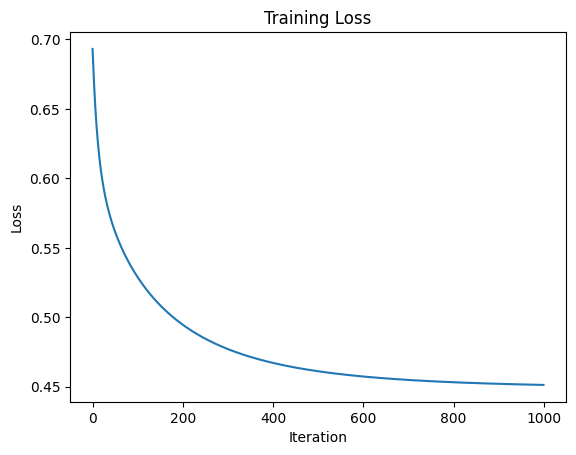

In [12]:
plt.plot(model.losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

## 8. Make Predictions

---

In [13]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

## 9. Model Evaluation

---


In [14]:
accuracy_value = accuracy(y_test, y_pred)
precision_value = precision(y_test, y_pred)
recall_value = recall(y_test, y_pred)
f1_value = f1_score(y_test, y_pred)

In [15]:
print(f"Accuracy: {accuracy_value:.3f}")
print(f"Precision: {precision_value:.3f}")
print(f"Recall: {recall_value:.3f}")
print(f"F1 Score: {f1_value:.3f}")

Accuracy: 0.836
Precision: 0.820
Recall: 0.735
F1 Score: 0.775


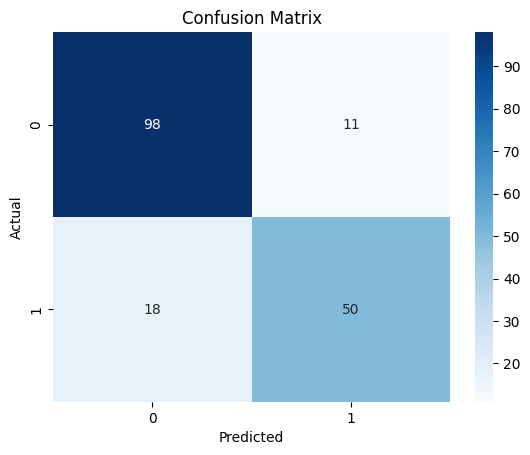

In [16]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 10 Comparison with scikit-learn implementation

---

Comparison of the custom NumPy logistic regression implementation with the scikit-learn implementation using the same train-test split and feature scaling.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [18]:
model_sk = LogisticRegression(max_iter=1000)
model_sk.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [19]:
y_pred_sk = model_sk.predict(X_test)
sklearn_proba = model_sk.predict_proba(X_test)[:, 1]

In [20]:
accuracy_sk = accuracy(y_test, y_pred_sk)
precision_sk = precision(y_test, y_pred_sk)
recall_sk = recall(y_test, y_pred_sk)
f1_sk = f1_score(y_test, y_pred_sk)
auc_sk = roc_auc_score(y_test, sklearn_proba)
auc_value = roc_auc_score(y_test, y_proba)

In [21]:
weights_comparison = pd.DataFrame(
    {
        "feature": list(X_train.columns) + ["bias"],
        "numpy_weight": list(model.w) + [model.b],
        "sklearn_weight": list(model_sk.coef_[0]) + [model_sk.intercept_[0]],
    }
)

weights_comparison

,feature,numpy_weight,sklearn_weight
0,sex,-2.492177,-2.621550
1,age,-0.502403,-0.539161
2,family_size,-0.475431,-0.473349
3,fare,0.191182,0.103753
4,1st_class,1.285087,1.123259
5,2nd_class,0.381839,-0.005833
6,3rd_class,-0.679411,-1.118588
7,bias,0.987516,1.437079


In [22]:
metrics = [
    ("Accuracy", accuracy_value, accuracy_sk),
    ("Precision", precision_value, precision_sk),
    ("Recall", recall_value, recall_sk),
    ("F1 Score", f1_value, f1_sk),
    ("AUC", auc_value, auc_sk),
]

print(f"{'Metric':<12} {'NumPy':<10} {'scikit-learn':<15}")
print("-" * 40)

for name, numpy_value, sklearn_value in metrics:
    print(f"{name:<12} {numpy_value:<10.3f} {sklearn_value:<15.3f}")

Metric       NumPy      scikit-learn   
----------------------------------------
Accuracy     0.836      0.831          
Precision    0.820      0.797          
Recall       0.735      0.750          
F1 Score     0.775      0.773          
AUC          0.870      0.871          


### Observations

The NumPy implementation achieved very similar overall performance to the scikit-learn model, showing that the custom logistic regression implementation successfully learned meaningful patterns from the dataset. The evaluation metrics and ROC AUC scores were nearly identical, indicating that both models learned a very similar decision boundary.

The NumPy implementation achieved slightly higher accuracy, precision, and F1 score, while the scikit-learn model achieved slightly higher recall and AUC. Overall, the results demonstrate that the custom implementation approximates the behavior of the optimized scikit-learn implementation closely while still exposing the underlying learning mechanics of logistic regression.

## 11 Conclusion

---

Compared to the scikit-learn baseline from notebook 02, the NumPy implementation achieved very similar overall behavior and evaluation performance, including nearly identical ROC AUC scores. The comparison of the learned weights and bias values also showed that both implementations converged toward very similar model parameters.

At the same time, implementing logistic regression from scratch exposed the internal mechanics of the algorithm, including probability prediction, sigmoid activation, loss computation, gradient calculation, and parameter updates through gradient descent. This helped build a deeper understanding of how machine learning models learn from data beyond using high-level library abstractions.